<a href="https://colab.research.google.com/github/elisama-of/EstatisticaPPEC/blob/main/AnaliseDaDurab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
categories:
- PPEC
- Ensino
- Estatística
date: 2026-07-09
description: Sexta Aula
image: regressao.png
title: "Aula 6 - Regressão Linear"
---

# Estatística Aplicada à Durabilidade de Concretos Convencionais, CAD e UHPC

## Análise Comparativa utilizando Correlação e Regressão Linear

### Autora
Elisama Freitas

---

# Objetivo

Aplicar ferramentas estatísticas para analisar comparativamente a durabilidade de concretos convencionais, Concretos de Alto Desempenho (CAD) e Ultra High Performance Concrete (UHPC).

O estudo utiliza:

- Correlação de Pearson;
- Correlação de Spearman;
- Regressão Linear;
- Análise exploratória de dados.

---

# Fundamentação Teórica

A durabilidade do concreto está relacionada à capacidade do material resistir à ação de agentes agressivos ao longo do tempo.

Entre os principais indicadores de durabilidade destacam-se:

- Resistência à compressão;
- Absorção de água;
- Penetração de cloretos;
- Porosidade;
- Permeabilidade.

A estatística é utilizada para identificar relações entre essas propriedades e compreender o comportamento dos diferentes tipos de concreto.

---

# Correlação

A correlação mede o grau de associação entre duas variáveis quantitativas.

## Interpretação do coeficiente de Pearson

- r próximo de +1 = forte correlação positiva;
- r próximo de -1 = forte correlação negativa;
- r próximo de 0 = ausência de correlação linear.

---

# Regressão Linear

A regressão linear permite modelar matematicamente a relação entre variáveis.

Neste trabalho será analisada a relação entre:

- Resistência à compressão;
- Penetração de cloretos.

A hipótese é que concretos mais resistentes apresentem menor penetração de agentes agressivos e maior durabilidade.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

from scipy.stats import pearsonr
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

# Banco de Dados

Os dados abaixo representam valores experimentais simulados compatíveis com concretos convencionais, CAD e UHPC.

As variáveis analisadas são:

- Resistência à compressão (MPa);
- Absorção de água (%);
- Penetração de cloretos (Coulombs).

In [10]:
dados = {

    'Tipo': ['Convencional']*10 + ['CAD']*10 + ['UHPC']*10,

    'Resistencia_MPa': [

        28,30,32,29,31,33,27,35,30,32,

        55,58,60,62,57,65,59,61,63,66,

        120,125,130,128,135,140,132,138,145,150
    ],

    'Absorcao_%': [

        8.5,8.0,7.8,8.2,7.9,7.5,8.7,7.2,8.1,7.7,

        5.2,5.0,4.8,4.5,5.1,4.3,4.7,4.6,4.4,4.2,

        1.8,1.7,1.5,1.6,1.4,1.3,1.5,1.2,1.1,1.0
    ],

    'Cloretos_Coulombs': [

        4200,4100,3900,4050,3950,3800,4300,3700,4000,3850,

        1800,1700,1600,1500,1750,1400,1650,1550,1450,1350,

        350,320,300,280,260,240,250,230,220,200
    ]
}

df = pd.DataFrame(dados)

# Faz a tabela começar em 1
df.index = df.index + 1

df

,Tipo,Resistencia_MPa,Absorcao_%,Cloretos_Coulombs
1,Convencional,28,8.5,4200
2,Convencional,30,8.0,4100
3,Convencional,32,7.8,3900
4,Convencional,29,8.2,4050
5,Convencional,31,7.9,3950
6,Convencional,33,7.5,3800
7,Convencional,27,8.7,4300
8,Convencional,35,7.2,3700
9,Convencional,30,8.1,4000
10,Convencional,32,7.7,3850


# Estatística Descritiva

A estatística descritiva permite visualizar:

- Média;
- Desvio padrão;
- Valores máximos;
- Valores mínimos.

Esses parâmetros ajudam na compreensão inicial do comportamento dos dados.

In [12]:
# Estatística descritiva com apenas 2 casas decimais

df.describe().round(2)

,Resistencia_MPa,Absorcao_%,Cloretos_Coulombs
count,30.00,30.00,30.00
mean,75.20,4.68,1941.67
std,44.64,2.74,1572.83
min,27.00,1.00,200.00
25%,32.25,1.62,305.00
50%,60.50,4.65,1575.00
75%,127.25,7.65,3837.50
max,150.00,8.70,4300.00


# Análise Exploratória

O gráfico de dispersão permite observar visualmente a relação entre:

- Resistência à compressão;
- Penetração de cloretos.

Espera-se comportamento inversamente proporcional:

- Quanto maior a resistência;
- Menor a penetração de cloretos.

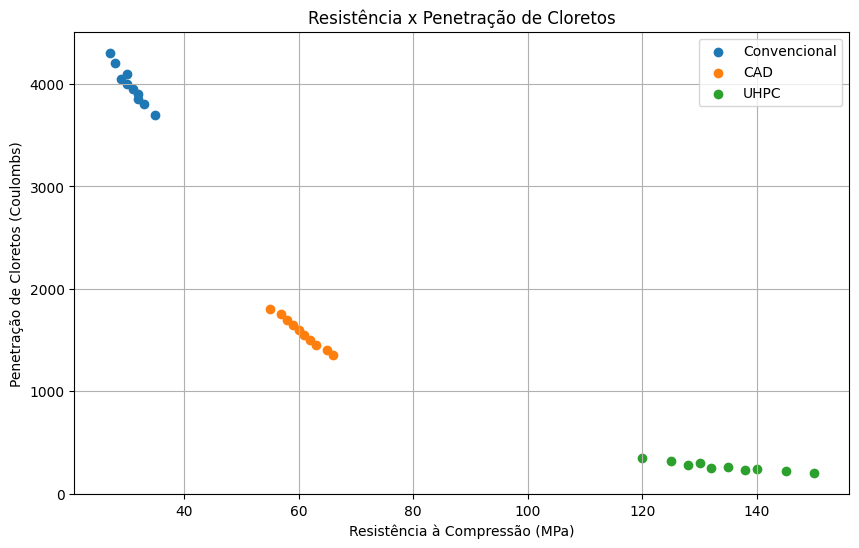

In [13]:
plt.figure(figsize=(10,6))

for tipo in df['Tipo'].unique():

    subset = df[df['Tipo'] == tipo]

    plt.scatter(
        subset['Resistencia_MPa'],
        subset['Cloretos_Coulombs'],
        label=tipo
    )

plt.xlabel('Resistência à Compressão (MPa)')
plt.ylabel('Penetração de Cloretos (Coulombs)')

plt.title('Resistência x Penetração de Cloretos')

plt.legend()

plt.grid(True)

plt.show()

# Correlação de Pearson

O coeficiente de Pearson mede a intensidade da relação linear entre variáveis quantitativas.

Neste estudo, deseja-se verificar a relação entre:

- Resistência mecânica;
- Durabilidade do concreto.

In [14]:
r, p = pearsonr(
    df['Resistencia_MPa'],
    df['Cloretos_Coulombs']
)

print(f'Coeficiente de Pearson: {r:.4f}')
print(f'Valor-p: {p:.6f}')

Coeficiente de Pearson: -0.9130
Valor-p: 0.000000


# Interpretação da Correlação

Valores negativos indicam que:

- À medida que a resistência aumenta;
- A penetração de cloretos diminui.

Isso demonstra melhoria da durabilidade dos concretos com maior desempenho mecânico.

O valor-p indica se a correlação possui significância estatística.

# Correlação de Spearman

A correlação de Spearman é uma técnica não paramétrica.

Ela é utilizada quando:
- Os dados não seguem distribuição normal;
- Há interesse em relações monotônicas entre variáveis.

In [15]:
rho, p_spear = spearmanr(
    df['Resistencia_MPa'],
    df['Cloretos_Coulombs']
)

print(f'Correlação de Spearman: {rho:.4f}')
print(f'Valor-p: {p_spear:.6f}')

Correlação de Spearman: -0.9978
Valor-p: 0.000000


# Regressão Linear

A regressão linear será utilizada para modelar matematicamente a relação entre:

- Resistência à compressão;
- Penetração de cloretos.

A reta de regressão representa a tendência geral dos dados.

In [16]:
X = df[['Resistencia_MPa']]

y = df['Cloretos_Coulombs']

modelo = LinearRegression()

modelo.fit(X, y)

predicoes = modelo.predict(X)

print('Coeficiente angular:', modelo.coef_[0])

print('Coeficiente linear:', modelo.intercept_)

Coeficiente angular: -32.170322634234815
Coeficiente linear: 4360.8749287611245


# Visualização da Regressão Linear

A reta ajustada representa a tendência matemática dos dados experimentais.

O modelo busca minimizar os erros entre:
- Valores observados;
- Valores previstos.

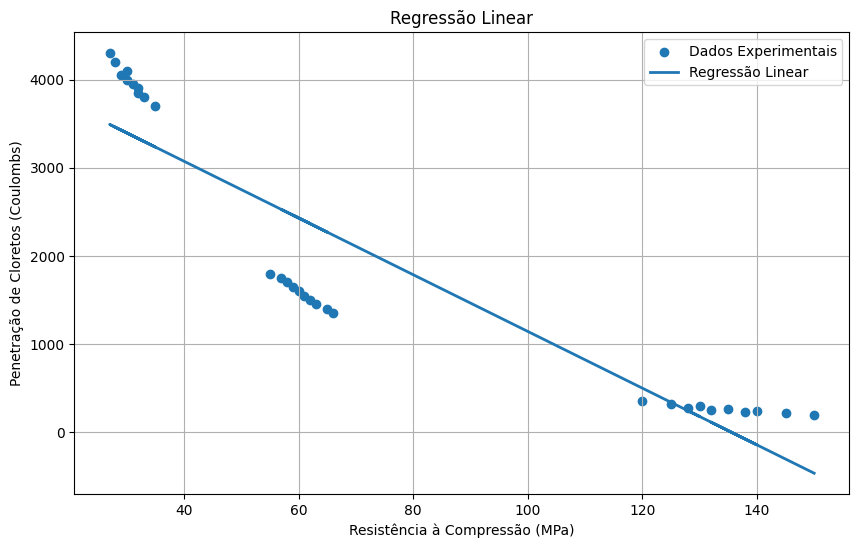

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Resistencia_MPa'],
    df['Cloretos_Coulombs'],
    label='Dados Experimentais'
)

plt.plot(
    df['Resistencia_MPa'],
    predicoes,
    linewidth=2,
    label='Regressão Linear'
)

plt.xlabel('Resistência à Compressão (MPa)')

plt.ylabel('Penetração de Cloretos (Coulombs)')

plt.title('Regressão Linear')

plt.legend()

plt.grid(True)

plt.show()

# Coeficiente de Determinação (R²)

O coeficiente de determinação indica quanto da variabilidade da variável dependente é explicada pelo modelo.

Valores próximos de 1 indicam:
- Excelente ajuste;
- Forte capacidade preditiva.

In [18]:
r2 = r2_score(y, predicoes)

mse = mean_squared_error(y, predicoes)

print(f'R²: {r2:.4f}')

print(f'Erro Quadrático Médio: {mse:.2f}')

R²: 0.8336
Erro Quadrático Médio: 397831.45


# Comparação entre os Tipos de Concreto

O boxplot permite comparar visualmente a distribuição da penetração de cloretos entre:

- Concreto Convencional;
- CAD;
- UHPC.

Valores menores indicam maior resistência à penetração de agentes agressivos.

<Figure size 800x500 with 0 Axes>

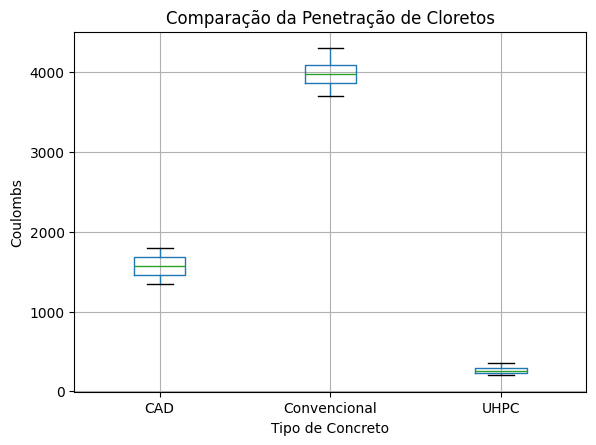

In [19]:
plt.figure(figsize=(8,5))

df.boxplot(
    column='Cloretos_Coulombs',
    by='Tipo'
)

plt.title('Comparação da Penetração de Cloretos')

plt.suptitle('')

plt.xlabel('Tipo de Concreto')

plt.ylabel('Coulombs')

plt.show()

# Discussão dos Resultados

Os resultados demonstram diferenças significativas entre os concretos analisados.

## Concreto Convencional

Apresentou:
- Maior absorção;
- Maior penetração de cloretos;
- Menor resistência mecânica.

Esses fatores indicam menor durabilidade.

---

## CAD

O concreto CAD apresentou:
- Melhor desempenho mecânico;
- Redução significativa da permeabilidade;
- Maior resistência à entrada de agentes agressivos.

---

## UHPC

O UHPC apresentou:
- Elevadíssima resistência mecânica;
- Baixíssima absorção;
- Excelente desempenho frente à penetração de cloretos.

Esses resultados estão relacionados:
- À matriz cimentícia mais densa;
- Ao refinamento dos poros;
- À baixa relação água/cimento.

---

# Análise Estatística

A análise estatística demonstrou forte relação entre:

- Resistência mecânica;
- Permeabilidade;
- Indicadores de durabilidade.

Os coeficientes de correlação e a regressão linear mostraram-se eficientes para descrever o comportamento dos concretos estudados.

# Conclusão

A aplicação de ferramentas estatísticas permitiu avaliar quantitativamente o comportamento dos concretos convencionais, CAD e UHPC.

Os resultados indicaram que:

- O aumento da resistência mecânica está associado à melhoria da durabilidade;
- Concretos mais densos apresentam menor penetração de agentes agressivos;
- O UHPC apresentou o melhor desempenho global.

A utilização de correlação e regressão linear mostrou-se eficiente para análise comparativa de materiais cimentícios.

